# Mineração de Processos na Construção Civil
## Análise de Fluxo de Obra com ProM e Python

---

## O que você vai aprender

Nesta aula prática, vamos usar um exemplo de obra para:
- criar um log de eventos a partir de registros de atividades;
- descobrir o processo real a partir dos dados;
- comparar o processo real com o processo planejado;
- identificar desvios e problemas na sequência de trabalho.

## Por que isso é importante?

Na construção civil, muitos problemas aparecem porque a obra não segue exatamente o planejado.
A mineração de processos mostra o que realmente aconteceu na obra usando os dados reais, não apenas o projeto.

### O que é um log de eventos?

Um log de eventos é uma tabela onde cada linha representa um evento do processo. No nosso exemplo:
- cada apartamento é um **caso**;
- cada atividade é um **evento**;
- cada evento tem data, hora e recurso responsável.

### Conceitos simples

| Conceito | O que significa |
|---|---|
| **Caso** | Um exemplo do processo — por exemplo, o apartamento 301 |
| **Evento** | Uma atividade registrada no tempo |
| **Atividade** | O nome da tarefa realizada |
| **Timestamp** | A data e hora do evento |
| **Log de eventos** | A tabela com todos os casos e eventos |
| **Rede de Petri** | O desenho que mostra as regras do processo |
| **Fitness** | Quanto o modelo explica os dados |
| **Precision** | Quanto o modelo evita comportamentos estranhos |

---

## Exemplo: ciclo de acabamento de um prédio residencial

Vamos simular um prédio com 20 apartamentos. O plano teórico de acabamento é:

```
Impermeabilização → Revestimento Parede → Revestimento Piso → Instalação Elétrica
    → Instalação Hidráulica → Pintura → Marcenaria → Vistoria Final
```

Na prática, podem ocorrer atrasos, retrabalhos e atividades fora de ordem. O log que vamos gerar tenta imitar esses problemas.

---

## Instalação das bibliotecas

In [3]:
# Instalação — execute apenas uma vez
# Se você já tem essas bibliotecas, pode pular esta célula
%pip install pm4py matplotlib pandas graphviz --quiet

Note: you may need to restart the kernel to use updated packages.


In [4]:
# ==============================================================================
# 1. BIBLIOTECAS BÁSICAS
# ==============================================================================
import pandas as pd              # Trabalha com tabelas de dados
import numpy as np               # Ajuda em cálculos e números
import matplotlib.pyplot as plt  # Desenha gráficos
import matplotlib.patches as mpatches # Usa cores e legendas nos gráficos
import warnings                  # Permite silenciar avisos do Python
warnings.filterwarnings('ignore') # Ignora avisos que não afetam a aula

# ==============================================================================
# 2. BIBLIOTECA DE MINERAÇÃO DE PROCESSOS
# ==============================================================================
import pm4py # Biblioteca principal de mineração de processos

# Objetos e conversores de log
from pm4py.objects.log.obj import EventLog, Trace, Event # Estruturas usadas pelo pm4py
from pm4py.objects.conversion.log import converter as log_converter # Converte DataFrame em log

# Algoritmos para descobrir processos a partir de dados
from pm4py.algo.discovery.alpha import algorithm as alpha_miner         # Alpha Miner
from pm4py.algo.discovery.heuristics import algorithm as heuristics_miner # Heuristics Miner
from pm4py.algo.discovery.inductive import algorithm as inductive_miner   # Inductive Miner

# Algoritmo que compara o log com um modelo
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay # Conformance via token replay

# Ferramentas para desenhar modelos
from pm4py.visualization.petri_net import visualizer as pn_visualizer   # Desenha redes de Petri
from pm4py.visualization.process_tree import visualizer as pt_visualizer # Desenha árvores de processo
from pm4py.visualization.heuristics_net import visualizer as hn_visualizer # Desenha redes heurísticas

# Estatísticas e variantes do log
from pm4py.statistics.traces.generic.log import case_statistics # Calcula estatísticas de cada caso
from pm4py.algo.filtering.log.variants import variants_filter   # Encontra variantes comuns

# ==============================================================================
# 3. TEMPO E SIMULAÇÃO
# ==============================================================================
from datetime import datetime, timedelta # Datas e durações
import random                            # Gera aleatoriedade nos desvios
import shutil

# ==============================================================================
# 4. CONFIGURAÇÃO DE REPRODUTIBILIDADE
# ==============================================================================
random.seed(42)   # Faz com que os resultados sejam iguais em cada execução
np.random.seed(42) # Também fixa a aleatoriedade do NumPy

print(f"pm4py versão: {pm4py.__version__}")
print("Bibliotecas carregadas com sucesso.")
# Verificação de Graphviz e helper para salvar imagens
from IPython.display import Image, display

GRAPHVIZ_AVAILABLE = shutil.which('dot') is not None
if not GRAPHVIZ_AVAILABLE:
    print("Aviso: Graphviz não encontrado no PATH. Geração de imagens de modelos será pulada.")

def save_graph_image(save_func, gviz, filename, model_name):
    if not GRAPHVIZ_AVAILABLE:
        print(f"Graphviz não encontrado no PATH. Pulando geração da imagem de {model_name}.")
        return
    try:
        save_func(gviz, filename)
        print(f"{model_name} salva: {filename}")
        display(Image(filename))
    except Exception as e:
        print(e)
        print(f"Não foi possível gerar a imagem de {model_name}. Verifique se Graphviz está instalado e se o executável 'dot' está no PATH.")


pm4py versão: 2.7.22.4
Bibliotecas carregadas com sucesso.
Aviso: Graphviz não encontrado no PATH. Geração de imagens de modelos será pulada.


---

## 4. Geração do Log de Eventos Sintético

Antes de usar os algoritmos, precisamos criar um log de eventos. Neste notebook, um log é uma tabela onde cada linha representa uma atividade feita em um apartamento.

Cada apartamento será um **caso** e cada atividade será um **evento** com data e hora.

O log criado terá variações comuns em obras reais:

- **Retrabalho** em algumas tarefas; assim, o exemplo fica mais próximo de uma obra de verdade, com erros e variações.

- **Troca de ordem** entre etapas que deveriam ser sequenciais;

- **Omissão** de vistoria final; e

- **Duração variável** de cada atividade.

In [5]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# ==============================================================================
# 1. PLANO TEÓRICO DA OBRA
# ==============================================================================
# Cada linha é uma atividade planejada e um tempo médio esperado (em dias)
ATIVIDADES = [
    ('Impermeabilizacao',     2), 
    ('Revestimento_Parede',   4), 
    ('Revestimento_Piso',     3), 
    ('Instalacao_Eletrica',   3), 
    ('Instalacao_Hidraulica', 3), 
    ('Pintura',               4), 
    ('Marcenaria',            5), 
    ('Vistoria_Final',        1), 
]

# Equipes que podem executar cada atividade
RECURSOS = {
    'Impermeabilizacao':     ['Equipe_Impermeabilizacao'],
    'Revestimento_Parede':   ['Equipe_Ceramica_A', 'Equipe_Ceramica_B'], 
    'Revestimento_Piso':     ['Equipe_Ceramica_A', 'Equipe_Ceramica_B'], 
    'Instalacao_Eletrica':   ['Equipe_Eletrica'],
    'Instalacao_Hidraulica': ['Equipe_Hidraulica'],
    'Pintura':               ['Equipe_Pintura_A', 'Equipe_Pintura_B'], 
    'Marcenaria':            ['Equipe_Marcenaria'],
    'Vistoria_Final':        ['Engenheiro_Residente'],
}

# ==============================================================================
# 2. SIMULAÇÃO (GERADOR DE DESVIOS TOTALMENTE DINÂMICO)
# ==============================================================================
def gerar_trace(apt_id, data_inicio):
    eventos = []
    ts = data_inicio
    sequencia = list(ATIVIDADES) 

    # MUDOU: Inversão Geral de Sequência (Ocorre em ~20% dos casos)
    if random.random() < 0.20:
        idx_e = next(i for i,a in enumerate(sequencia) if a[0]=='Instalacao_Eletrica')
        idx_h = next(i for i,a in enumerate(sequencia) if a[0]=='Instalacao_Hidraulica')
        sequencia[idx_e], sequencia[idx_h] = sequencia[idx_h], sequencia[idx_e]

    # LOOP PRINCIPAL: Processando cada atividade da sequência
    for atividade, dur_media in sequencia:
        
        # MUDOU: Falha de Registro Geral (Ocorre em ~5% de QUALQUER atividade)
        # Se o gatilho disparar, a atividade acontece na obra, mas o registro é perdido (Omissão).
        if random.random() < 0.05:
            continue # Pula o registro do evento atual no log, fazendo o número cair abaixo de 20

        dur = max(1, int(np.random.normal(dur_media, dur_media * 0.4)))
        recurso = random.choice(RECURSOS[atividade])

        eventos.append({
            'case:concept:name': f'APT_{apt_id:02d}',     
            'concept:name':      atividade,               
            'time:timestamp':    ts,                      
            'org:resource':      recurso,                 
            'lifecycle:transition': 'complete',           
        })
        ts += timedelta(days=dur)

        # --------------------------------------------------------------------------
        # NOVO: Erros específicos para destravar as atividades que estavam fixas
        # --------------------------------------------------------------------------

        # 1. Falha no Teste de Estanqueidade (~15% de chance) -> Refazer Impermeabilização
        if atividade == 'Impermeabilizacao' and random.random() < 0.15:
            ts += timedelta(days=1)
            eventos.append({
                'case:concept:name': f'APT_{apt_id:02d}',
                'concept:name':      'Impermeabilizacao',
                'time:timestamp':    ts,
                'org:resource':      random.choice(RECURSOS['Impermeabilizacao']),
                'lifecycle:transition': 'complete',
            })
            ts += timedelta(days=2)

        # 2. Erro de Paginação ou Peças Quebradas (~20% de chance) -> Refazer Revestimento Parede
        if atividade == 'Revestimento_Parede' and random.random() < 0.20:
            ts += timedelta(days=1)
            eventos.append({
                'case:concept:name': f'APT_{apt_id:02d}',
                'concept:name':      'Revestimento_Parede',
                'time:timestamp':    ts,
                'org:resource':      random.choice(RECURSOS['Revestimento_Parede']),
                'lifecycle:transition': 'complete',
            })
            ts += timedelta(days=2)

        # 3. Vazamento em Junções Hidráulicas (~15% de chance) -> Retrabalho na Hidráulica
        if atividade == 'Instalacao_Hidraulica' and random.random() < 0.15:
            ts += timedelta(days=1)
            eventos.append({
                'case:concept:name': f'APT_{apt_id:02d}',
                'concept:name':      'Instalacao_Hidraulica',
                'time:timestamp':    ts,
                'org:resource':      random.choice(RECURSOS['Instalacao_Hidraulica']),
                'lifecycle:transition': 'complete',
            })
            ts += timedelta(days=1)

        # 4. Furto de Fiação ou Ajuste de Tomada (~10% de chance) -> Retrabalho na Elétrica
        if atividade == 'Instalacao_Eletrica' and random.random() < 0.10:
            ts += timedelta(days=1)
            eventos.append({
                'case:concept:name': f'APT_{apt_id:02d}',
                'concept:name':      'Instalacao_Eletrica',
                'time:timestamp':    ts,
                'org:resource':      random.choice(RECURSOS['Instalacao_Eletrica']),
                'lifecycle:transition': 'complete',
            })
            ts += timedelta(days=1)

        # 5. Erro nas Dimensões dos Módulos (~15% de chance) -> Ajuste de Marcenaria
        if atividade == 'Marcenaria' and random.random() < 0.15:
            ts += timedelta(days=2) # Tempo de ajuste na oficina
            eventos.append({
                'case:concept:name': f'APT_{apt_id:02d}',
                'concept:name':      'Marcenaria',
                'time:timestamp':    ts,
                'org:resource':      random.choice(RECURSOS['Marcenaria']),
                'lifecycle:transition': 'complete',
            })
            ts += timedelta(days=2)

        # Retrabalhos originais mantidos (Piso e Pintura)
        if atividade == 'Revestimento_Piso' and random.random() < 0.25:
            ts += timedelta(days=1)  
            eventos.append({
                'case:concept:name': f'APT_{apt_id:02d}',
                'concept:name':      'Revestimento_Piso',  
                'time:timestamp':    ts,
                'org:resource':      random.choice(RECURSOS['Revestimento_Piso']), 
                'lifecycle:transition': 'complete',
            })
            ts += timedelta(days=2) 

        if atividade == 'Marcenaria' and random.random() < 0.20:
            ts += timedelta(days=1)
            eventos.append({
                'case:concept:name': f'APT_{apt_id:02d}',
                'concept:name':      'Pintura', 
                'time:timestamp':    ts,
                'org:resource':      random.choice(RECURSOS['Pintura']),
                'lifecycle:transition': 'complete',
            })
            ts += timedelta(days=2)

    # Vistoria Final Omissão mantida
    if random.random() < 0.15:
        eventos = [e for e in eventos if e['concept:name'] != 'Vistoria_Final']

    return eventos

# ==============================================================================
# 3. GERAÇÃO E CONSOLIDAÇÃO DO LOG DE EVENTOS DA OBRA INTEIRA
# ==============================================================================
todos_eventos = []
data_inicio_obra = datetime(2026, 1, 1)

for apt in range(1, 21):
    offset = timedelta(days=random.randint(0, 30))
    todos_eventos.extend(gerar_trace(apt, data_inicio_obra + offset))

df_log = pd.DataFrame(todos_eventos)
df_log['time:timestamp'] = pd.to_datetime(df_log['time:timestamp'])
df_log = df_log.sort_values(['case:concept:name','time:timestamp']).reset_index(drop=True)

# Converte o DataFrame em um EventLog do pm4py para os algoritmos de descoberta
log = log_converter.apply(df_log, variant=log_converter.Variants.TO_EVENT_LOG)

print(f"Total de eventos: {len(df_log)}")
print(f"Total de casos (apartamentos): {df_log['case:concept:name'].nunique()}")
print(f"\nDistribuição dinâmica de atividades nesta rodada:")

print(df_log['concept:name'].value_counts().to_string())

Total de eventos: 174
Total de casos (apartamentos): 20

Distribuição dinâmica de atividades nesta rodada:
concept:name
Revestimento_Piso        27
Pintura                  23
Instalacao_Eletrica      23
Impermeabilizacao        22
Marcenaria               22
Revestimento_Parede      21
Instalacao_Hidraulica    19
Vistoria_Final           17


### 4.1 Visualização Exploratória do Log

Nesta seção são realizadas duas análises exploratórias do log de eventos. A primeira contabiliza a frequência de execução de cada atividade, permitindo identificar quais etapas concentram maior volume de trabalho e possíveis indícios de retrabalho ou desvios. A segunda reconstrói a linha do tempo de cada apartamento em um gráfico semelhante a um diagrama de Gantt, possibilitando visualizar a sequência e a duração relativa das atividades. Na Engenharia Civil, essas análises auxiliam o gerente de projetos a compreender a distribuição das atividades, identificar gargalos, comparar o desempenho entre unidades e apoiar decisões sobre alocação de equipes, equipamentos e demais recursos ao longo da execução da obra.

Figura salva com sucesso em: img/aula_construcao/gantt_obra.png


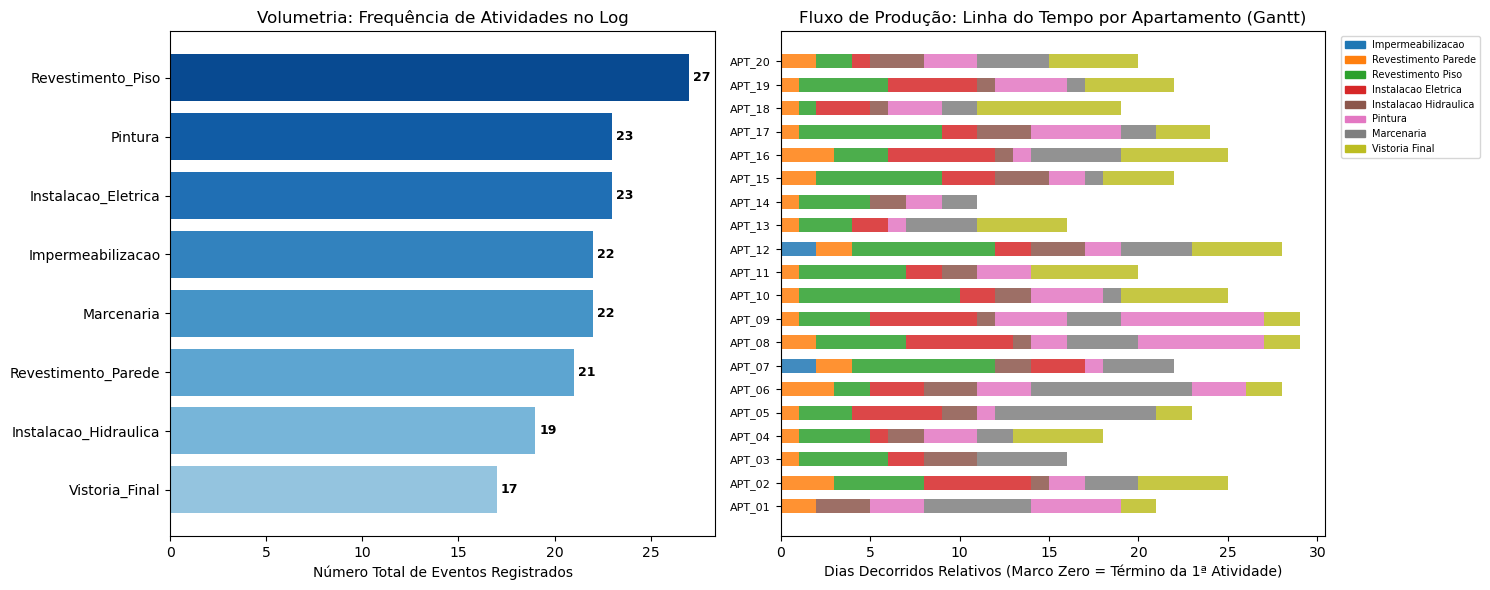

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# Configura a área de desenho com dois gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ==============================================================================
# GRÁFICO 1: FREQUÊNCIA DE ATIVIDADES (Volumetria do Canteiro)
# ==============================================================================
# Conta a ocorrência de cada atividade no log (exõe retrabalhos e omissões)
contagem = df_log['concept:name'].value_counts()

# Cria um degradê de cores azul (do escuro para o claro) baseado no total de tarefas
cores = plt.cm.Blues(np.linspace(0.4, 0.9, len(contagem)))

# Plota as barras horizontais invertendo a paleta para que o maior valor fique mais escuro
axes[0].barh(contagem.index, contagem.values, color=cores[::-1])
axes[0].set_xlabel('Número Total de Eventos Registrados')
axes[0].set_title('Volumetria: Frequência de Atividades no Log')
axes[0].invert_yaxis() # Mantém a atividade mais frequente no topo do gráfico

# Adiciona os rótulos numéricos exatos na ponta de cada barra para facilitar a leitura
for i, v in enumerate(contagem.values):
    axes[0].text(v + 0.2, i, str(v), va='center', fontsize=9, fontweight='bold')

# ==============================================================================
# GRÁFICO 2: LINHA DO TEMPO RECONSTRUÍDA (Gantt Realista por Apartamento)
# ==============================================================================
# Extrai e ordena a lista de apartamentos únicos (Casos)
apt_list = sorted(df_log['case:concept:name'].unique())

# Mapeia uma cor única e estática para cada atividade baseada na lista teórica original
atividade_cores = {
    a: plt.cm.tab10(i / len(ATIVIDADES)) for i, (a, _) in enumerate(ATIVIDADES)
}

# Varre cada apartamento para desenhar sua respectiva linha cronológica
for y_idx, apt in enumerate(apt_list):
    # Isola os eventos do apartamento atual e garante a ordenação cronológica perfeita
    eventos_apt = df_log[df_log['case:concept:name'] == apt].sort_values('time:timestamp').copy()
    
    # Define o marco zero (o primeiro registro de término do apartamento)
    ts_min = eventos_apt['time:timestamp'].min()
    
    # CORREÇÃO CRÍTICA: Inicializa o ponteiro de início da primeira atividade da linha como 0
    start_day = 0 
    
    for _, row in eventos_apt.iterrows():
        # Calcula em qual dia relativo o evento atual terminou
        end_day = (row['time:timestamp'] - ts_min).days
        
        # Se por flutuação estatística o end_day for menor que o start_day, força a duração mínima de 1 dia
        if end_day < start_day:
            end_day = start_day + 1
            
        # A duração real da barra é a diferença entre o dia que acabou e o dia que começou
        duration = end_day - start_day
        
        # Recupera a cor da atividade (aplica cinza caso surja alguma atividade não mapeada)
        cor = atividade_cores.get(row['concept:name'], 'gray')
        
        # Plota a barra: left é onde começou, width é a duração real calculada
        axes[1].barh(y_idx, width=duration, left=start_day, height=0.6, color=cor, alpha=0.85)
        
        # AVANÇA O PONTEIRO: O início da próxima atividade será exatamente o término desta
        start_day = end_day

# Configurações de eixo e legenda do Gantt
axes[1].set_yticks(range(len(apt_list)))
axes[1].set_yticklabels(apt_list, fontsize=8)
axes[1].set_xlabel('Dias Decorridos Relativos (Marco Zero = Término da 1ª Atividade)')
axes[1].set_title('Fluxo de Produção: Linha do Tempo por Apartamento (Gantt)')

# Cria as legendas customizadas removendo os underlines dos nomes das tarefas
patches = [mpatches.Patch(color=atividade_cores[a], label=a.replace('_',' '))
           for a, _ in ATIVIDADES if a in atividade_cores]
axes[1].legend(handles=patches, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=7, ncol=1, frameon=True)

# Ajusta o espaçamento das margens para evitar cortes nos textos
plt.tight_layout()

# Salva o arquivo final em alta resolução (DPI 150) eliminando bordas brancas sobressalentes
# O 'r' antes das aspas garante que o Windows entenda as barras invertidas corretamente
# Caminho relativo direto a partir da pasta 'mineracaoProcessos' onde está o seu notebook
caminho_salvamento = r"img/aula_construcao/gantt_obra.png"

# Cria a pasta 'aula_construcao' caso ela ainda não exista no diretório
os.makedirs(os.path.dirname(caminho_salvamento), exist_ok=True)

# Salva o gráfico antes do encerramento da figura pelo plt.show()
plt.savefig(caminho_salvamento, dpi=150, bbox_inches='tight')
print(f"Figura salva com sucesso em: {caminho_salvamento}")
plt.show()

---

## 5. Exportação para XES e Carregamento no pm4py

O formato **XES** (*eXtensible Event Stream*) é o padrão IEEE 1849 para logs de eventos. O ProM importa nativamente arquivos `.xes`. A biblioteca `pm4py` escreve e lê XES com a mesma estrutura, permitindo que o notebook e o ProM utilizem **exatamente o mesmo arquivo**.

In [7]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
from collections import defaultdict

# ==== GERAÇÃO DO df_log (igual ao seu) ====
# ... (mantenha seu código de geração aqui) ...

# ==== EXPORTA XES MANUALMENTE (sem pm4py.write_xes) ====
def df_to_xes(df, filepath):
    lines = ['<?xml version="1.0" encoding="UTF-8" ?>',
             '<log xes.version="1.0" xmlns="http://www.xes-standard.org/">',
             '  <extension name="Concept" prefix="concept" uri="http://www.xes-standard.org/concept.xesext"/>',
             '  <extension name="Time" prefix="time" uri="http://www.xes-standard.org/time.xesext"/>',
             '  <extension name="Organizational" prefix="org" uri="http://www.xes-standard.org/org.xesext"/>']
    
    for case_id, group in df.groupby('case:concept:name'):
        lines.append(f'  <trace>')
        lines.append(f'    <string key="concept:name" value="{case_id}"/>')
        for _, row in group.iterrows():
            ts = row['time:timestamp'].strftime('%Y-%m-%dT%H:%M:%S.000+00:00')
            lines.append(f'    <event>')
            lines.append(f'      <string key="concept:name" value="{row["concept:name"]}"/>')
            lines.append(f'      <date key="time:timestamp" value="{ts}"/>')
            lines.append(f'      <string key="org:resource" value="{row["org:resource"]}"/>')
            lines.append(f'      <string key="lifecycle:transition" value="{row["lifecycle:transition"]}"/>')
            lines.append(f'    </event>')
        lines.append(f'  </trace>')
    
    lines.append('</log>')
    with open(filepath, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines))

df_to_xes(df_log, 'obra_residencial.xes')
print("XES exportado com sucesso")

# ==== VARIANTES DIRETO DO df_log (sem pm4py) ====
variantes_dict = defaultdict(list)
for case_id, group in df_log.sort_values('time:timestamp').groupby('case:concept:name'):
    seq = tuple(group['concept:name'].tolist())
    variantes_dict[seq].append(case_id)

variantes_ordenadas = sorted(variantes_dict.items(), key=lambda x: len(x[1]), reverse=True)

print(f"\nTotal de variantes identificadas: {len(variantes_ordenadas)}\n")
print(f"{'#':<4} {'Frequência':<12} Sequência de Atividades")
print("-" * 100)
for i, (seq, cases) in enumerate(variantes_ordenadas, 1):
    ativs = ' → '.join([str(a).replace('_', ' ') for a in seq])
    print(f"{i:<4} {len(cases):<12} {ativs}")

print()
variante_principal = variantes_ordenadas[0]
print(f"Variante mais frequente ({len(variante_principal[1])} casos — processo dominante):")
print(' → '.join([str(a).replace('_', ' ') for a in variante_principal[0]]))

XES exportado com sucesso

Total de variantes identificadas: 14

#    Frequência   Sequência de Atividades
----------------------------------------------------------------------------------------------------
1    4            Impermeabilizacao → Revestimento Parede → Revestimento Piso → Instalacao Eletrica → Instalacao Hidraulica → Pintura → Marcenaria → Vistoria Final
2    3            Impermeabilizacao → Revestimento Parede → Revestimento Piso → Instalacao Eletrica → Instalacao Eletrica → Instalacao Hidraulica → Pintura → Marcenaria → Vistoria Final
3    2            Impermeabilizacao → Revestimento Parede → Revestimento Piso → Revestimento Piso → Instalacao Eletrica → Instalacao Hidraulica → Pintura → Marcenaria → Vistoria Final
4    1            Impermeabilizacao → Revestimento Parede → Instalacao Hidraulica → Pintura → Marcenaria → Pintura → Vistoria Final
5    1            Impermeabilizacao → Revestimento Parede → Revestimento Piso → Revestimento Piso → Instalacao Eletrica → Inst

### 5.1 Como abrir o arquivo XES no ProM

> **Passo a passo — ProM 6.x (GUI)**
>
> 1. Abra o **ProM 6** (Java, disponível em [https://www.promtools.org](https://www.promtools.org)).
> 2. No painel *Workspace*, clique em **Import** → selecione `obra_residencial.xes`.
> 3. O ProM carregará o log e exibirá o resumo: número de traces, eventos e variantes.
> 4. Com o log selecionado no Workspace, clique em **Analyse** para acessar os algoritmos de descoberta.
>
> O restante desta aula reproduz no Python os mesmos resultados que você obteria no ProM, com as mesmas interpretações.

---

### 5.2. Análise de Variantes

Variantes (*variants*) são as sequências únicas de atividades observadas no log. Um log com poucas variantes indica processo padronizado; muitas variantes indicam alta variabilidade operacional.

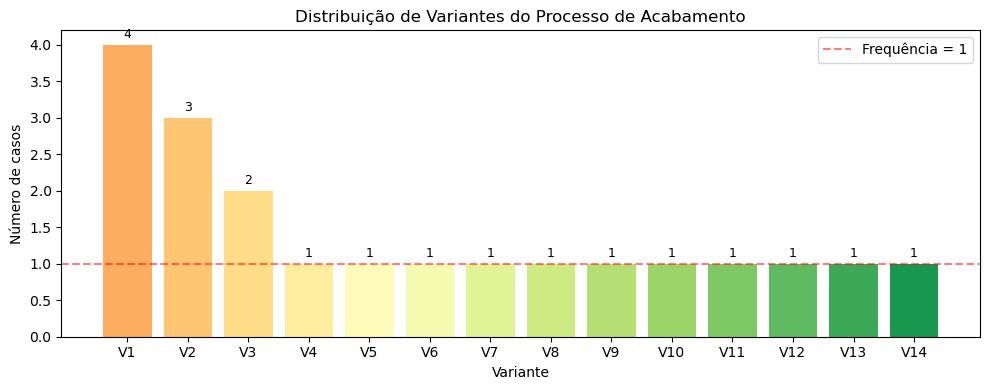

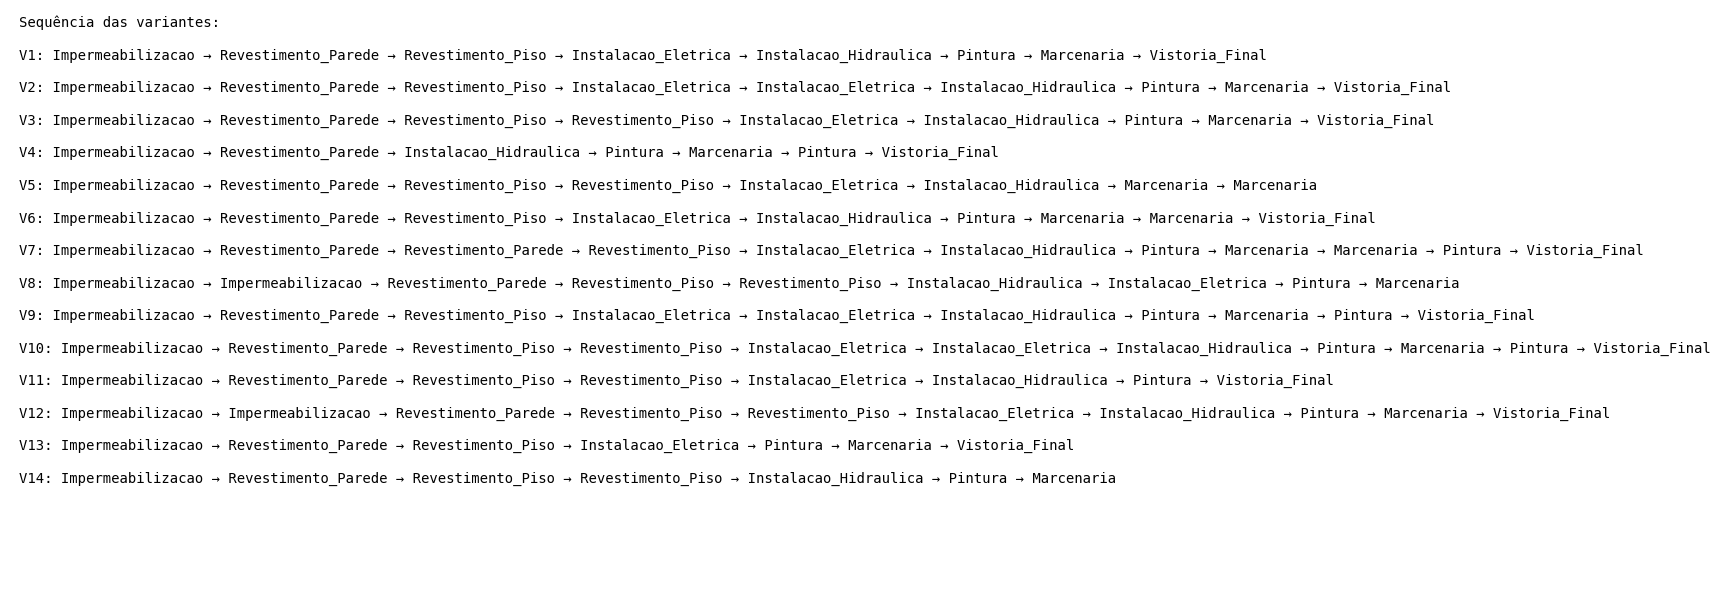

In [14]:
# Gráfico de distribuição de variantes
freqs = [len(t) for _, t in variantes_ordenadas]
labels = [f"V{i+1}" for i in range(len(freqs))]

fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.bar(
    labels,
    freqs,
    color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(freqs)))
)

ax.set_xlabel('Variante')
ax.set_ylabel('Número de casos')
ax.set_title('Distribuição de Variantes do Processo de Acabamento')

# Exibe a frequência sobre cada barra
for bar, freq in zip(bars, freqs):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        str(freq),
        ha='center',
        va='bottom',
        fontsize=9
    )

# Linha de referência
ax.axhline(
    y=1,
    color='red',
    linestyle='--',
    alpha=0.5,
    label='Frequência = 1'
)

ax.legend()

plt.tight_layout()

# Salva o gráfico
plt.savefig('variantes.png', dpi=150, bbox_inches='tight')

plt.show()


# =====================================================
# Figura 2 - Legenda das variantes
# =====================================================

texto_legenda = "Sequência das variantes:\n\n"

for i, (variante, traces) in enumerate(variantes_ordenadas):
    sequencia = " → ".join(variante)
    texto_legenda += f"V{i+1}: {sequencia}\n\n"

fig = plt.figure(figsize=(15, max(4, len(variantes_ordenadas)*0.45)))

plt.axis('off')

plt.text(
    0.01,
    0.99,
    texto_legenda,
    fontsize=10,
    family='monospace',
    va='top'
)

plt.tight_layout()

# Salva a legenda
plt.savefig('variantes_legenda.png', dpi=150, bbox_inches='tight')

plt.show()

---

# 6. Descoberta de Processos com o Inductive Visual Miner

Após compreender as características do log de eventos por meio das análises exploratórias, o próximo passo consiste em descobrir automaticamente o processo que originou esses registros. Nesta etapa será utilizado o **Inductive Visual Miner**, disponível no ProM, que constrói um modelo do processo a partir do log e disponibiliza recursos interativos para sua análise. O objetivo é compreender como o processo realmente ocorre, identificar caminhos alternativos, visualizar gargalos e comparar a execução observada com o fluxo esperado do empreendimento.

---

## 6.1 O algoritmo Inductive Miner

O Inductive Miner é um dos algoritmos de descoberta de processos mais utilizados atualmente por produzir modelos consistentes e robustos, mesmo quando o log contém ruídos ou variações naturais da execução. Diferentemente de algoritmos clássicos, como o Alpha Miner, ele identifica automaticamente estruturas como:

* sequência de atividades;
* atividades executadas em paralelo;
* pontos de decisão;
* laços (loops);
* caminhos opcionais.

O resultado é um modelo consistente (*sound*), reduzindo problemas como estados inacessíveis, bloqueios (*deadlocks*) e inconsistências estruturais.

---

### 6.2 Por que utilizar o Inductive Visual Miner

O plugin desenvolvido por **Sander Leemans** amplia as funcionalidades do Inductive Miner ao integrar descoberta do processo, animação do fluxo e análise de desempenho em uma única interface.

Entre seus principais recursos destacam-se:

* descoberta automática do modelo;
* visualização dinâmica do fluxo dos casos;
* conversão automática para Rede de Petri;
* animação da execução dos eventos;
* filtragem de ruído (*noise threshold*);
* análise de tempos e gargalos;
* visualização das variantes mais relevantes.

Por esse motivo, atualmente ele é considerado uma das principais ferramentas de mineração de processos para aplicações práticas.

---

### 6.3 Executando o plugin no ProM

1. Importe o arquivo XES utilizando o **OpenXES Importer**.

2. Selecione o log na área de trabalho.

3. Clique em **Visualize with Inductive Visual Miner**.

4. Ajuste o parâmetro **Noise Threshold**.

Como referência:

* **0,0** → utiliza todos os eventos registrados;
* **0,2** → recomendado para logs reais com pequenas variações;
* **valores maiores** → simplificam o modelo, eliminando comportamentos pouco frequentes.

5. Execute o algoritmo.

---

### 6.4 Interpretando o modelo descoberto

Após a execução, o ProM apresenta um modelo contendo o fluxo descoberto.

Durante a análise, procure identificar:

* atividades executadas obrigatoriamente;
* caminhos alternativos;
* paralelismo entre atividades;
* retrabalhos;
* loops;
* atividades pouco frequentes.

Esses elementos representam o comportamento real observado no log e podem diferir do processo originalmente planejado.

---

## 6.5 Explorando os recursos do Inductive Visual Miner

Além da descoberta do processo, o plugin disponibiliza diversas visualizações que auxiliam na interpretação dos resultados.

O vídeo a seguir apresenta a execução completa do plugin **Inductive Visual Miner** no ProM.

<video width="100%" controls preload="metadata">
    <source src="img/aula_construcao/IndVisualMiner_2026-07-01_115625.mp4" type="video/mp4">
    Seu navegador não suporta vídeos HTML5.
</video>



---

### Frequência das atividades

Mostra quais atividades concentram maior número de ocorrências.

Explicação:

> Quanto mais espessa ou intensa a representação gráfica, maior o número de casos que percorreu aquela atividade.

---

### Frequência dos caminhos

Permite identificar quais transições entre atividades são mais utilizadas.


---

### Animação da execução

O plugin permite reproduzir o fluxo temporal dos casos.


Essa funcionalidade facilita compreender como diferentes casos percorrem o processo ao longo do tempo.

---

### Tempos de execução

É possível colorir o modelo conforme os tempos médios de permanência.

Atividades com maiores tempos normalmente representam potenciais gargalos do processo.

---

### Filtragem de ruído

O parâmetro **Noise Threshold** permite simplificar o modelo.


Essa comparação mostra como pequenas variações podem ser removidas para destacar o fluxo predominante.

---

## 6.6 Aplicação na Engenharia Civil

Na Engenharia Civil, o Inductive Visual Miner permite descobrir como os processos realmente são executados em obras, independentemente do planejamento inicialmente previsto. O modelo descoberto evidencia desvios de sequência, retrabalhos, atividades executadas em paralelo e variações entre diferentes unidades construtivas. Essas informações auxiliam o gerente de projetos na identificação de gargalos, na avaliação da aderência ao processo planejado, na revisão dos cronogramas, na padronização de procedimentos e na melhoria contínua da execução de empreendimentos futuros.

---

## Considerando a mineração aplicada à Engenharia Civil, sugere-se a geração dos seguintes exemplos:

1. **Importação do log no ProM.**
2. **Seleção do plugin Inductive Visual Miner.**
3. **Modelo descoberto (visão principal).**
4. **Visualização por frequência das atividades.**
5. **Visualização por frequência dos caminhos (arestas).**
6. **Animação do fluxo (uma captura durante a reprodução).**
7. **Mapa de desempenho/tempo (Performance).**
8. **Comparação entre dois valores de *Noise Threshold* (0,0 × 0,2).**


## 9. Análise de Conformidade (*Conformance Checking*)

A conformidade compara o **log real** com um **modelo normativo** e aponta onde o processo diverge.

### 9.1 Qual rede usar

A melhor rede para essa análise é a **Rede de Petri gerada pelo Inductive Miner**. Ela é sound e reflete melhor os caminhos reais do processo.

Não use a Heuristic Net nesta etapa se ela não estiver disponível no ProM atual.

### 9.2 Como executar no ProM

> 1. Selecione o log e o modelo de Petri no *Workspace*.
> 2. Clique em **Analyse**.
> 3. Busque por **Replay a Log on a Petri Net for Conformance Analysis**.
> 4. Configure os custos:
>    - *Move on Log* = 1;
>    - *Move on Model* = 1;
>    - *Move on Silent Transition* = 0 ou padrão.
> 5. Execute o replay.

### 9.3 O que observar

- **Fitness**: quanto do log pode ser reproduzido pelo modelo.
- **Desvios por atividade**: quais etapas fugiram do fluxo esperado.
- **Traces não conformes**: onde o processo real se desviou.



## 10. Análise de Desempenho (*Performance Analysis*)

A análise de desempenho mostra tempo e fluxo de trabalho, complementando a conformidade.

### 10.1 O que ela mostra

- duração de cada atividade;
- tempo de espera entre etapas;
- gargalos de ciclo;
- variação entre casos.

Para a engenharia civil, isso revela etapas que atrasam a obra, fases com alto retrabalho e atividades de maior dispersão de tempo.

### 10.2 Como executar no ProM

> 1. Selecione o log no *Workspace*.
> 2. Clique em **Analyse**.
> 3. Use plugins como **Performance Spectrum** ou **Dotted Chart**.
> 4. Observe:
>    - barras de tempo para cada atividade;
>    - distribuição de duração; 
>    - sequência de eventos no tempo.

### 10.3 Interpretação para a obra

- ciclos longos podem indicar retrabalho ou espera por material;
- alta dispersão aponta falta de padronização;
- atividades críticas devem ser priorizadas em ações corretivas.



In [9]:
# Análise de duração por atividade
# Para cada atividade, calculamos a diferença temporal entre eventos consecutivos no mesmo trace

duracoes = {a: [] for a, _ in ATIVIDADES}

for trace in log:
    for i in range(len(trace) - 1):
        atividade = trace[i]['concept:name']
        ts_atual = trace[i]['time:timestamp']
        ts_prox  = trace[i+1]['time:timestamp']
        dur_dias = (ts_prox - ts_atual).days
        if atividade in duracoes and dur_dias > 0:
            duracoes[atividade].append(dur_dias)

# Estatísticas
print(f"{'Atividade':<30} {'N':>5} {'Mín':>5} {'Méd':>6} {'Máx':>5} {'DP':>6}")
print("-" * 58)
for atividade, _ in ATIVIDADES:
    vals = duracoes[atividade]
    if vals:
        print(f"{atividade:<30} {len(vals):>5} {min(vals):>5.1f} "
              f"{np.mean(vals):>6.1f} {max(vals):>5.1f} {np.std(vals):>6.2f}")

Atividade                          N   Mín    Méd   Máx     DP
----------------------------------------------------------
Impermeabilizacao                 22   1.0    1.5   3.0   0.66
Revestimento_Parede               21   1.0    3.4   7.0   1.53
Revestimento_Piso                 27   1.0    2.6   5.0   1.19
Instalacao_Eletrica               23   1.0    2.2   4.0   1.06
Instalacao_Hidraulica             19   1.0    2.7   5.0   1.08
Pintura                           23   1.0    3.0   6.0   1.49
Marcenaria                        19   2.0    5.1   8.0   1.54


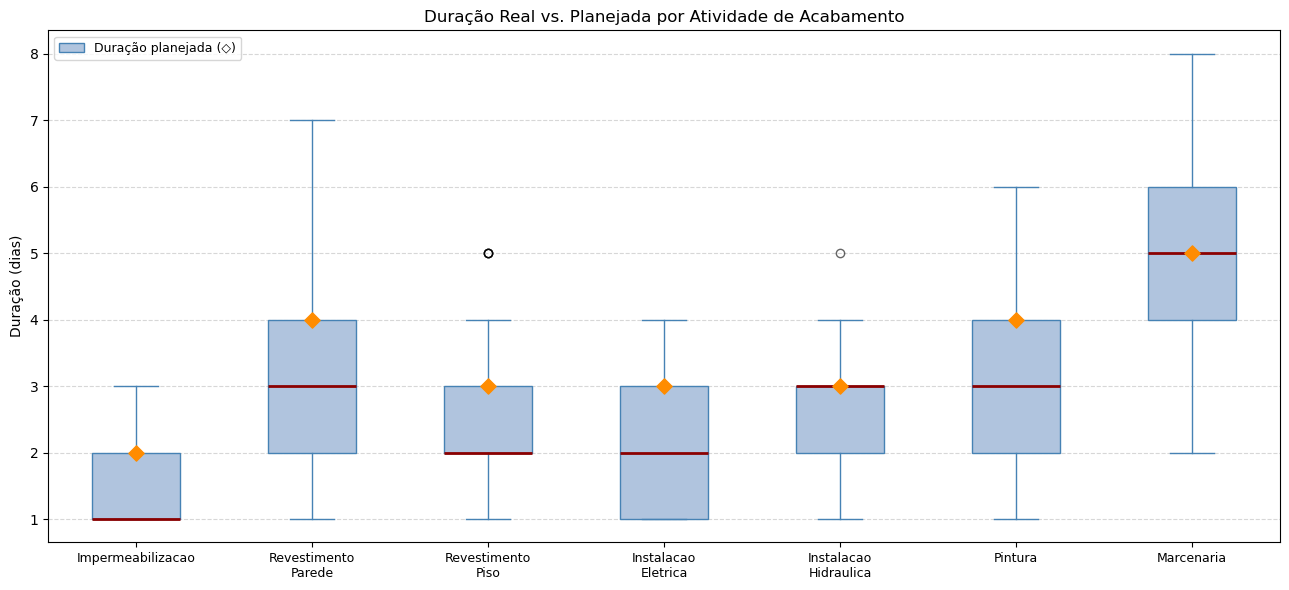

In [10]:
# Boxplot de durações por atividade
atividades_validas = [a for a, _ in ATIVIDADES if duracoes[a]]
dados_box = [duracoes[a] for a in atividades_validas]
labels_box = [a.replace('_', '\n') for a in atividades_validas]

fig, ax = plt.subplots(figsize=(13, 6))
bp = ax.boxplot(dados_box, patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue', color='steelblue'),
                medianprops=dict(color='darkred', linewidth=2),
                whiskerprops=dict(color='steelblue'),
                capprops=dict(color='steelblue'),
                flierprops=dict(marker='o', color='tomato', alpha=0.6))

# Linha do planejado
planejado = {a: d for a, d in ATIVIDADES}
for i, atividade in enumerate(atividades_validas, 1):
    ax.scatter(i, planejado.get(atividade, 0), marker='D',
               color='darkorange', s=60, zorder=5, label='Planejado' if i==1 else '')

ax.set_xticks(range(1, len(atividades_validas)+1))
ax.set_xticklabels(labels_box, fontsize=9)
ax.set_ylabel('Duração (dias)')
ax.set_title('Duração Real vs. Planejada por Atividade de Acabamento')
ax.legend(['Duração planejada (◇)'], fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('duracao_atividades.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Análise de Recursos

A análise de recursos mostra quem faz o quê e onde há sobrecargas.

### 11.1 O que precisa

- um atributo de recurso no log (`resource`, `originator`, `org`);
- informações sobre equipes ou subcontratados;
- correspondência entre eventos e responsáveis.

### 11.2 Como usar no ProM

> 1. Se o log contém recursos, selecione-o no *Workspace*.
> 2. Clique em **Analyse**.
> 3. Busque plugins de recurso ou performance que aceitem atributos de recurso.
> 4. Verifique:
>    - carga de trabalho por função ou equipe;
>    - atividades com maior número de eventos;
>    - responsáveis por desvios ou retrabalhos.

### 11.3 Benefício para a engenharia civil

- identifica equipes sobrecarregadas;
- detecta problemas de coordenação entre disciplinas;
- ajuda a planejar mão de obra e alocação.



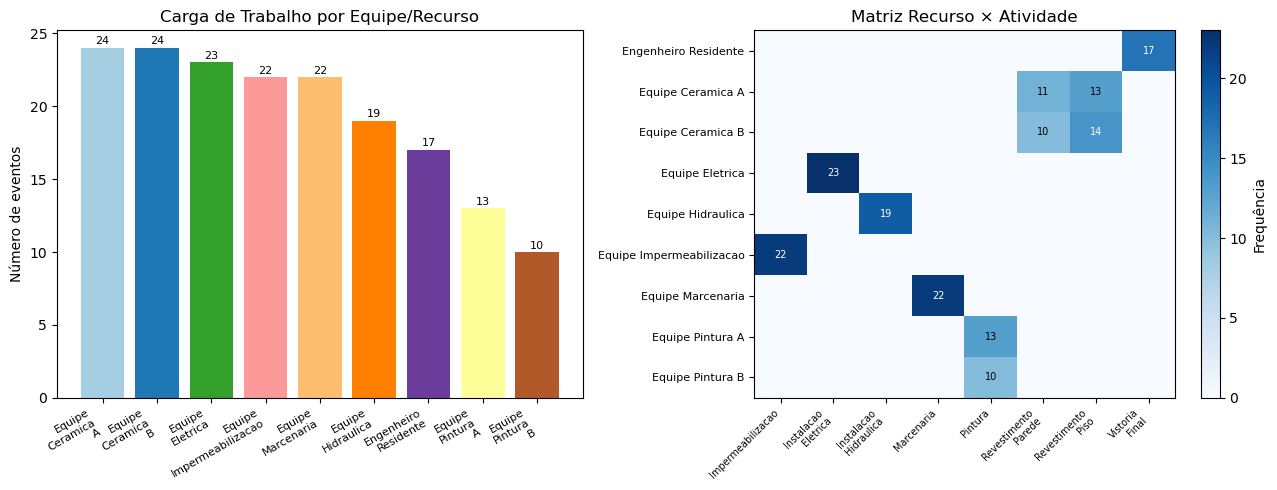

In [11]:
# Carga de trabalho por recurso
carga = df_log['org:resource'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Eventos por recurso
cores_r = plt.cm.Paired(np.linspace(0, 1, len(carga)))
axes[0].bar(range(len(carga)), carga.values, color=cores_r)
axes[0].set_xticks(range(len(carga)))
axes[0].set_xticklabels([r.replace('_', '\n') for r in carga.index], fontsize=8, rotation=30, ha='right')
axes[0].set_ylabel('Número de eventos')
axes[0].set_title('Carga de Trabalho por Equipe/Recurso')
for i, v in enumerate(carga.values):
    axes[0].text(i, v + 0.1, str(v), ha='center', va='bottom', fontsize=8)

# Matriz recurso x atividade
matriz = pd.crosstab(df_log['org:resource'], df_log['concept:name'])
im = axes[1].imshow(matriz.values, cmap='Blues', aspect='auto')
axes[1].set_xticks(range(len(matriz.columns)))
axes[1].set_xticklabels([c.replace('_', '\n') for c in matriz.columns], fontsize=7, rotation=45, ha='right')
axes[1].set_yticks(range(len(matriz.index)))
axes[1].set_yticklabels([r.replace('_', ' ') for r in matriz.index], fontsize=8)
axes[1].set_title('Matriz Recurso × Atividade')
plt.colorbar(im, ax=axes[1], label='Frequência')

# Anotações na matriz
for i in range(len(matriz.index)):
    for j in range(len(matriz.columns)):
        val = matriz.values[i, j]
        if val > 0:
            axes[1].text(j, i, str(val), ha='center', va='center', fontsize=7,
                        color='white' if val > matriz.values.max()*0.6 else 'black')

plt.tight_layout()
plt.savefig('recursos.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Identificação de Não Conformidades Específicas

A mineração de processos permite mapear desvios concretos do fluxo esperado:
- etapas executadas fora de ordem;
- retrabalhos repetidos;
- saltos de atividades;
- atrasos de sequência.

No contexto da obra, esses desvios podem indicar:
- falta de coordenação entre equipes;
- problemas de sequenciamento de materiais;
- entregas parciais sem inspeção.

### 13.1 Como usar o modelo

- use o modelo do Inductive Miner como referência principal;
- compare o log real com o modelo para encontrar pontos de não conformidade;
- registre as atividades e os casos com maior número de desvios.



In [12]:
# Identificação de desvios específicos
desvios = {
    'retrabalho_piso': [],
    'inversao_hidro_eletrica': [],
    'vistoria_ausente': [],
    'conforme': [],
}

for trace in log:
    apt = trace.attributes.get('concept:name', '?')
    atividades_trace = [e['concept:name'] for e in trace]
    tem_desvio = False

    # Retrabalho: Revestimento_Piso aparece mais de uma vez
    if atividades_trace.count('Revestimento_Piso') > 1:
        desvios['retrabalho_piso'].append(apt)
        tem_desvio = True

    # Inversão: Instalacao_Hidraulica antes de Instalacao_Eletrica
    if ('Instalacao_Hidraulica' in atividades_trace and
        'Instalacao_Eletrica' in atividades_trace):
        idx_h = atividades_trace.index('Instalacao_Hidraulica')
        idx_e = atividades_trace.index('Instalacao_Eletrica')
        if idx_h < idx_e:
            desvios['inversao_hidro_eletrica'].append(apt)
            tem_desvio = True

    # Vistoria ausente
    if 'Vistoria_Final' not in atividades_trace:
        desvios['vistoria_ausente'].append(apt)
        tem_desvio = True

    if not tem_desvio:
        desvios['conforme'].append(apt)

print("=" * 55)
print("    RELATÓRIO DE NÃO CONFORMIDADES")
print("=" * 55)
print(f"\n✗ Retrabalho em Revestimento Piso ({len(desvios['retrabalho_piso'])} casos):")
print(f"  {', '.join(desvios['retrabalho_piso']) or 'Nenhum'}")
print(f"\n✗ Inversão Hidráulica → Elétrica ({len(desvios['inversao_hidro_eletrica'])} casos):")
print(f"  {', '.join(desvios['inversao_hidro_eletrica']) or 'Nenhum'}")
print(f"\n✗ Vistoria Final Ausente ({len(desvios['vistoria_ausente'])} casos) [CRÍTICO]:")
print(f"  {', '.join(desvios['vistoria_ausente']) or 'Nenhum'}")
print(f"\n✓ Totalmente conformes ({len(desvios['conforme'])} casos):")
print(f"  {', '.join(desvios['conforme']) or 'Nenhum'}")

    RELATÓRIO DE NÃO CONFORMIDADES

✗ Retrabalho em Revestimento Piso (8 casos):
  APT_03, APT_07, APT_09, APT_10, APT_11, APT_12, APT_14, APT_17

✗ Inversão Hidráulica → Elétrica (1 casos):
  APT_07

✗ Vistoria Final Ausente (3 casos) [CRÍTICO]:
  APT_03, APT_07, APT_14

✓ Totalmente conformes (12 casos):
  APT_01, APT_02, APT_04, APT_05, APT_06, APT_08, APT_13, APT_15, APT_16, APT_18, APT_19, APT_20


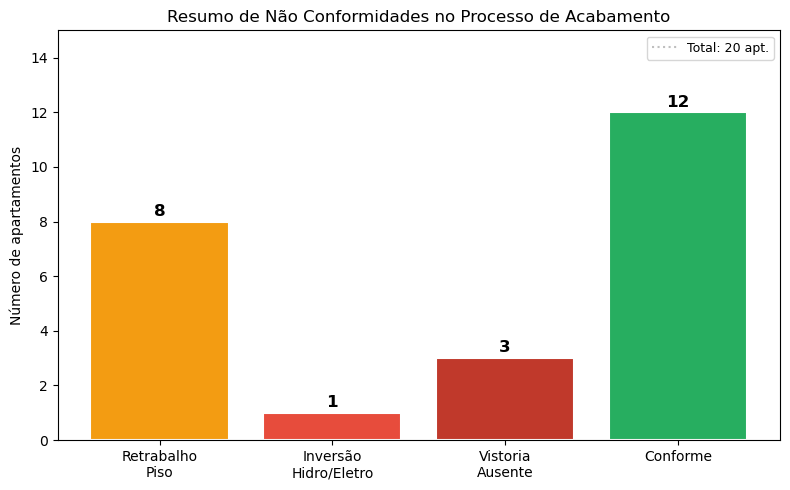

In [13]:
# Gráfico de resumo de não conformidades
tipos_nc = ['Retrabalho\nPiso', 'Inversão\nHidro/Eletro', 'Vistoria\nAusente', 'Conforme']
qtds_nc  = [len(desvios['retrabalho_piso']),
            len(desvios['inversao_hidro_eletrica']),
            len(desvios['vistoria_ausente']),
            len(desvios['conforme'])]
cores_nc = ['#f39c12', '#e74c3c', '#c0392b', '#27ae60']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(tipos_nc, qtds_nc, color=cores_nc, edgecolor='white', linewidth=1.5)
ax.set_ylabel('Número de apartamentos')
ax.set_title('Resumo de Não Conformidades no Processo de Acabamento')
ax.set_ylim(0, max(qtds_nc) + 3)
for bar, qtd in zip(bars, qtds_nc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(qtd), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.axhline(y=len(log), color='gray', linestyle=':', alpha=0.5, label=f'Total: {len(log)} apt.')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('nao_conformidades.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Discussão dos Resultados

### 14.1 Interpretação dos Modelos Descobertos

O **Alpha Miner** é útil para verificar se a sequência geral da obra está correta. Ele tende a confirmar o fluxo planejado, mas não é robusto para loops complexos e retrabalho.

O **Inductive Miner** é a melhor escolha para este conteúdo:
- capta retrabalhos reais;
- gera um modelo sound;
- permite comparar o processo real com o planejado com maior confiança.

### 14.2 O que o engenheiro civil aprende

- se o processo seguiu a ordem prevista;
- quais atividades causaram desvio;
- onde há maior risco de atraso;
- como a visualização do ProM ajuda a comunicar falhas de execução.

## 15. Exercício Proposto [sem. 2026.1]

Considerando o exemplo inspirado em cinco escolas públicas já analisadas no projeto.O exercício deve ser transversal e consolidar as cinco escolas para identificar padrões comuns e variações entre unidades. Use os resultados para comparar o planejado x executado.

Esses exemplos podem ser combinados com redes de Petri e CPN já desenvolvidas, e com análises temporais ou estatísticas em R.

Analise, entre outros, os principais resultados do exercício; conclusões operacionais; e  ideias de melhoria para o processo.

